In [1]:
import pandas as pd
import numpy as np
import os
from timeseries_utils import read_daily_timeseries_csv

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]  = 300
plt.style.use('dark_background')

In [75]:
"""
Prompt to devstral (The final functions had to be modified to get them working):
You are an expert python data analyst, and you have been given the following task. There is a dataset called pet, that has been read to a pandas DataFrame. The column names are measurement location ids, while the index is a daily datetime index ranging from 1981 to 2023. pet has been created by combining evaporation information from three different sources. snow_e has been used whenever snow_depth has been more than one. FMI is available for months 4 to 9 and has been used if there hasn't been snow and it's available. Finally, the remaining gaps have been filled with singer.

Please write the following functions in python
First function takes the four described files, and returns a dataframe where it has been marked which dataset is being used.

Second function takes the output of first function, finds the transition times and returns those as a dataframe that contains the transition timestamps for all locations

Third function calculates the min, median and max change in values at the transition point for a given pair of source datasets (fmi, singer or snow_e) for all the locations and returns that.

Fourth function calculates the average variation of the previous four days before the transition, using the dataset that is "active" at that time.

Fifth is the same as fourth, but for the four days after transition

Sixth function splits a given dataframe with datetime index to first and second half of the year, using 183rd day of the year as a cutoff.
"""


def mark_dataset_usage(snow_depth, fmi, singer, snow_e):
    """
    Marks which dataset is being used in each cell of the combined PET dataframe.

    Parameters:
    snow_depth (DataFrame): Snow depth data
    fmi (DataFrame): FMI evaporation data
    singer (DataFrame): Singer evaporation data
    snow_e (DataFrame): Snow evaporation data

    Returns:
    DataFrame: Original PET data with an additional level in columns indicating source
    """
    

    # Reindex fmi to include all dates (will be NaN outside months 4-9)
    fmi = fmi.reindex(snow_depth.index)
    # Create a copy of the original PET data (assuming it's already combined)
    # Here we'll reconstruct it to demonstrate the logic
    pet = pd.DataFrame(index=snow_depth.index)

    # Initialize source tracking
    source = pd.DataFrame(index=snow_depth.index, columns=snow_depth.columns)
    
    mask_snow = snow_depth > 1
    source[mask_snow] = 'snow_e'
    mask_fmi = (fmi.notna()) & (~mask_snow)
    source[mask_fmi] = 'fmi'
    mask_singer = (~mask_snow) & (~mask_fmi)
    source[mask_singer] = 'singer'
    
    return source

def find_transition_times(source_df):
    """
    Finds transition times between datasets for all locations.

    Parameters:
    source_df (DataFrame): Output from mark_dataset_usage showing data sources

    Returns:
    DataFrame: Transition timestamps for all locations
    """
    transitions = []

    for col in source_df.columns:
        # Get the source series for this location
        sources = source_df[col]

        # Find where the source changes (and isn't NaN)
        source_changes = sources[sources != sources.shift(1)].dropna()

        # Get the timestamps of changes
        for timestamp in source_changes.index:
            transitions.append({
                'location': col,
                'timestamp': timestamp,
                'from': sources.shift(1).loc[timestamp],
                'to': sources.loc[timestamp]
            })

    return pd.DataFrame(transitions)

def find_transition_times(source_df):
    """
    Finds transition times between datasets for all locations.

    Parameters:
    source_df (DataFrame): Output from mark_dataset_usage showing data sources

    Returns:
    DataFrame: Transition timestamps for all locations
    """
    transitions = []

    for col in source_df.columns:
        # Get the source series for this location
        sources = source_df[col]

        # Find where the source changes (and isn't NaN)
        source_changes = sources[sources != sources.shift(1)].dropna()

        # Get the timestamps of changes
        for timestamp in source_changes.index:
            transitions.append({
                'location': col,
                'timestamp': timestamp,
                'from': sources.shift(1).loc[timestamp],
                'to': sources.loc[timestamp]
            })

    return pd.DataFrame(transitions)

def calculate_transition_changes(pet_df, source_df, transitions, from_source, to_source):
    """
    Calculates statistics of PET value changes at transition points between two sources,
    including 25th and 75th percentiles.

    Parameters:
    pet_df (DataFrame): The actual PET values
    source_df (DataFrame): Source tracking from mark_dataset_usage
    from_source (str): Source before transition ('FMI', 'singer', or 'snow_e')
    to_source (str): Source after transition

    Returns:
    DataFrame: Statistics of value changes at transitions, including:
              - min_change
              - percentile_25
              - median_change
              - percentile_75
              - max_change
              - count
    """
    # Get all transitions between the specified sources
    relevant_trans = transitions[
        (transitions['from'] == from_source) &
        (transitions['to'] == to_source)
    ]

    changes = []

    for _, row in relevant_trans.iterrows():
        loc = row['location']
        timestamp = row['timestamp']
        # Pet is more limited in length compared
        if timestamp < pd.Timestamp("1981-01-01"):
            continue

        # Get values before and after transition
        val_before = pet_df.loc[timestamp - pd.Timedelta(days=1), loc]
        val_after = pet_df.loc[timestamp, loc]

        change = val_after - val_before
        changes.append(change)

    if not changes:
        return pd.DataFrame()  # No transitions found

    

    stats = {
        'min_change': np.min(changes),
        'percentile_25': np.percentile(changes, 25),
        'median_change': np.median(changes),
        'mean_change': np.mean(changes),
        'avg_variation': np.std(changes),
        'percentile_75': np.percentile(changes, 75),
        'max_change': np.max(changes),
        'count': len(changes)
    }

    return pd.DataFrame([stats], index=[f"{from_source}_to_{to_source}"])

def calculate_pre_transition_variation(pet_df, source_df, transition_df, days=4):
    """
    Calculates average variation of PET values in the N days before transition.

    Parameters:
    pet_df (DataFrame): The actual PET values
    source_df (DataFrame): Source tracking
    transition_df (DataFrame): Output from find_transition_times
    days (int): Number of days to consider

    Returns:
    DataFrame: Average variation for each transition
    """
    results = []

    for _, row in transition_df.iterrows():
        loc = row['location']
        timestamp = row['timestamp']
        source = row['from']

        # Get the previous N days of data
        start_date = timestamp - pd.Timedelta(days=days)
        pre_data = pet_df.loc[start_date:timestamp - pd.Timedelta(days=1), loc]

        if len(pre_data) < days:
            continue  # Not enough data

        # Calculate variation (standard deviation)
        variation = pre_data.std()

        results.append({
            'location': loc,
            'timestamp': timestamp,
            'source': source,
            'avg_variation': variation
        })

    return pd.DataFrame(results)

def calculate_post_transition_variation(pet_df, source_df, transition_df, days=4):
    """
    Calculates average variation of PET values in the N days after transition.

    Parameters:
    pet_df (DataFrame): The actual PET values
    source_df (DataFrame): Source tracking
    transition_df (DataFrame): Output from find_transition_times
    days (int): Number of days to consider

    Returns:
    DataFrame: Average variation for each transition
    """
    results = []

    for _, row in transition_df.iterrows():
        loc = row['location']
        timestamp = row['timestamp']
        source = row['to']

        # Get the next N days of data
        end_date = timestamp + pd.Timedelta(days=days)
        post_data = pet_df.loc[timestamp + pd.Timedelta(days=1):end_date, loc]

        if len(post_data) < days:
            continue  # Not enough data

        # Calculate variation (standard deviation)
        variation = post_data.std()

        results.append({
            'location': loc,
            'timestamp': timestamp,
            'source': source,
            'avg_variation': variation
        })

    return pd.DataFrame(results)

def filter_isolated_transitions(transitions_df, min_days_between=30):
    """
    Filters transitions to only include those that don't have another transition
    for the same location within n days.

    Parameters:
    transitions_df (DataFrame): Output from find_transition_times
    min_days_between (int): Minimum number of days required between transitions
                           for the same location (default: 30)

    Returns:
    DataFrame: Filtered transitions with sufficient spacing
    """
    # Sort by location and timestamp to ensure proper grouping
    sorted_trans = transitions_df.sort_values(['location', 'timestamp']).copy()

    # Initialize list to store filtered transitions
    filtered_trans = []

    # Group by location and process each location's transitions
    for loc, group in sorted_trans.groupby('location'):
        # Get all timestamps for this location
        timestamps = group['timestamp'].values

        # Calculate time differences between consecutive transitions
        time_diffs = np.diff(timestamps) / np.timedelta64(1, 'D')  # Convert to days

        # Find transitions that are sufficiently spaced
        # First transition is always included
        keep_indices = [0]

        for i in range(1, len(time_diffs)):
            if np.absolute(time_diffs[i]) >= min_days_between:
                keep_indices.append(i+1)  # +1 because diff is between i and i+1

        # Add the qualifying transitions to our filtered list
        filtered_trans.extend(group.iloc[keep_indices].to_dict('records'))

    return pd.DataFrame(filtered_trans)


def split_year_halves(df):
    """
    Splits a DataFrame with datetime index into first and second half of the year.

    Parameters:
    df (DataFrame): Input DataFrame with datetime index

    Returns:
    tuple: (first_half, second_half) DataFrames
    """
    first_half = df[df['timestamp'].dt.dayofyear <= 183]
    second_half = df[df['timestamp'].dt.dayofyear > 183]
    return first_half, second_half

In [3]:
root = '/media/iielse/T9/CAMELS-FI/data/timeseries-by-attribute/'
pet_path = os.path.join(root, 'pet.csv')
fmi_path = os.path.join(root, 'pet_fmi.csv')
singer_path = os.path.join(root, 'pet_singer.csv')
snow_e_path = os.path.join(root, 'snow_evaporation.csv')
snow_path = os.path.join(root, 'snow_depth.csv')
# For getting another view on things
humidity_path = os.path.join(root, 'humidity_rel.csv')

pet = read_daily_timeseries_csv(pet_path)
fmi = read_daily_timeseries_csv(fmi_path)
singer = read_daily_timeseries_csv(singer_path)
snow_e = read_daily_timeseries_csv(snow_e_path)
snow_depth = read_daily_timeseries_csv(snow_path)
humidity = read_daily_timeseries_csv(humidity_path)

In [4]:
pet

,896,905,907,908,923,924,929,930,931,933,...,3602,3605,3607,3678,3719,3727,3728,3850,3907,3975
date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,0.11,0.07,0.09,0.10,0.12,0.11,0.05,0.11,0.09,0.11,...,0.11,0.12,0.23,0.16,0.09,-0.03,-0.04,0.03,0.16,0.06
1981-01-02,0.25,0.04,0.04,0.05,0.07,0.09,0.20,0.03,0.03,0.04,...,0.16,0.14,0.06,0.07,0.11,-0.00,-0.01,0.38,0.07,0.36
1981-01-03,0.00,-0.01,-0.01,-0.01,-0.01,-0.01,0.01,-0.01,-0.01,-0.01,...,-0.01,-0.03,0.02,-0.04,-0.07,-0.01,-0.01,-0.01,-0.04,-0.01
1981-01-04,0.04,-0.01,-0.01,-0.01,-0.01,-0.01,0.03,0.00,-0.00,-0.00,...,0.05,-0.03,0.02,-0.00,-0.06,-0.02,-0.02,0.05,0.02,0.05
1981-01-05,0.06,-0.01,-0.01,-0.01,-0.01,-0.01,0.04,-0.00,-0.01,-0.01,...,0.07,0.07,0.00,0.06,0.04,-0.01,-0.01,0.15,0.07,0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,-0.02,-0.01,-0.01,-0.01,-0.02,-0.02,-0.02,-0.01,-0.01,-0.01,...,-0.01,-0.01,-0.01,0.00,-0.08,-0.01,-0.01,-0.01,0.05,-0.00
2023-12-28,-0.01,-0.01,-0.01,-0.01,-0.01,-0.02,-0.03,0.01,0.01,-0.01,...,-0.01,-0.05,-0.02,0.01,-0.04,-0.01,-0.01,-0.04,0.01,-0.02
2023-12-29,0.01,-0.01,-0.01,-0.01,-0.01,-0.02,-0.02,0.00,-0.00,-0.01,...,0.03,0.13,0.14,0.12,0.07,-0.01,-0.01,0.03,0.10,0.08


In [5]:
fmi

,896,905,907,908,923,924,929,930,931,933,...,3602,3605,3607,3678,3719,3727,3728,3850,3907,3975
date,,,,,,,,,,,,,,,,,,,,,
1981-04-01,1.0,1.0,0.9,0.9,1.0,1.0,1.1,1.0,0.9,0.9,...,1.2,1.6,1.2,1.5,1.6,1.0,1.0,1.1,1.4,1.2
1981-04-02,1.3,1.4,1.4,1.4,1.4,1.3,1.3,1.4,1.4,1.4,...,1.4,1.3,1.1,1.1,1.2,1.1,1.1,1.3,1.1,1.3
1981-04-03,1.1,1.0,1.0,1.0,1.1,1.0,1.2,1.1,1.1,1.1,...,1.2,1.1,1.3,1.1,1.1,1.0,1.1,1.0,1.1,1.0
1981-04-04,1.3,1.2,1.1,1.2,1.3,1.2,1.3,1.2,1.1,1.1,...,1.3,1.6,1.2,1.6,1.7,1.2,1.2,1.5,1.6,1.5
1981-04-05,1.3,1.3,1.2,1.3,1.4,1.4,1.3,1.1,1.1,1.1,...,1.3,1.4,1.0,1.4,1.5,0.9,0.9,1.3,1.3,1.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-26,0.8,1.0,1.0,1.0,1.0,1.1,1.1,1.0,1.0,1.0,...,1.0,1.0,1.1,1.1,1.1,0.7,0.7,1.1,1.1,1.1
2023-09-27,0.6,0.7,0.7,0.7,0.6,0.7,0.8,0.6,0.5,0.6,...,0.7,0.7,0.6,0.7,0.7,0.4,0.4,1.0,0.7,0.9
2023-09-28,0.7,0.6,0.6,0.7,0.7,0.7,0.8,0.7,0.6,0.7,...,0.8,1.0,0.7,0.9,1.0,0.5,0.5,0.9,0.9,0.9


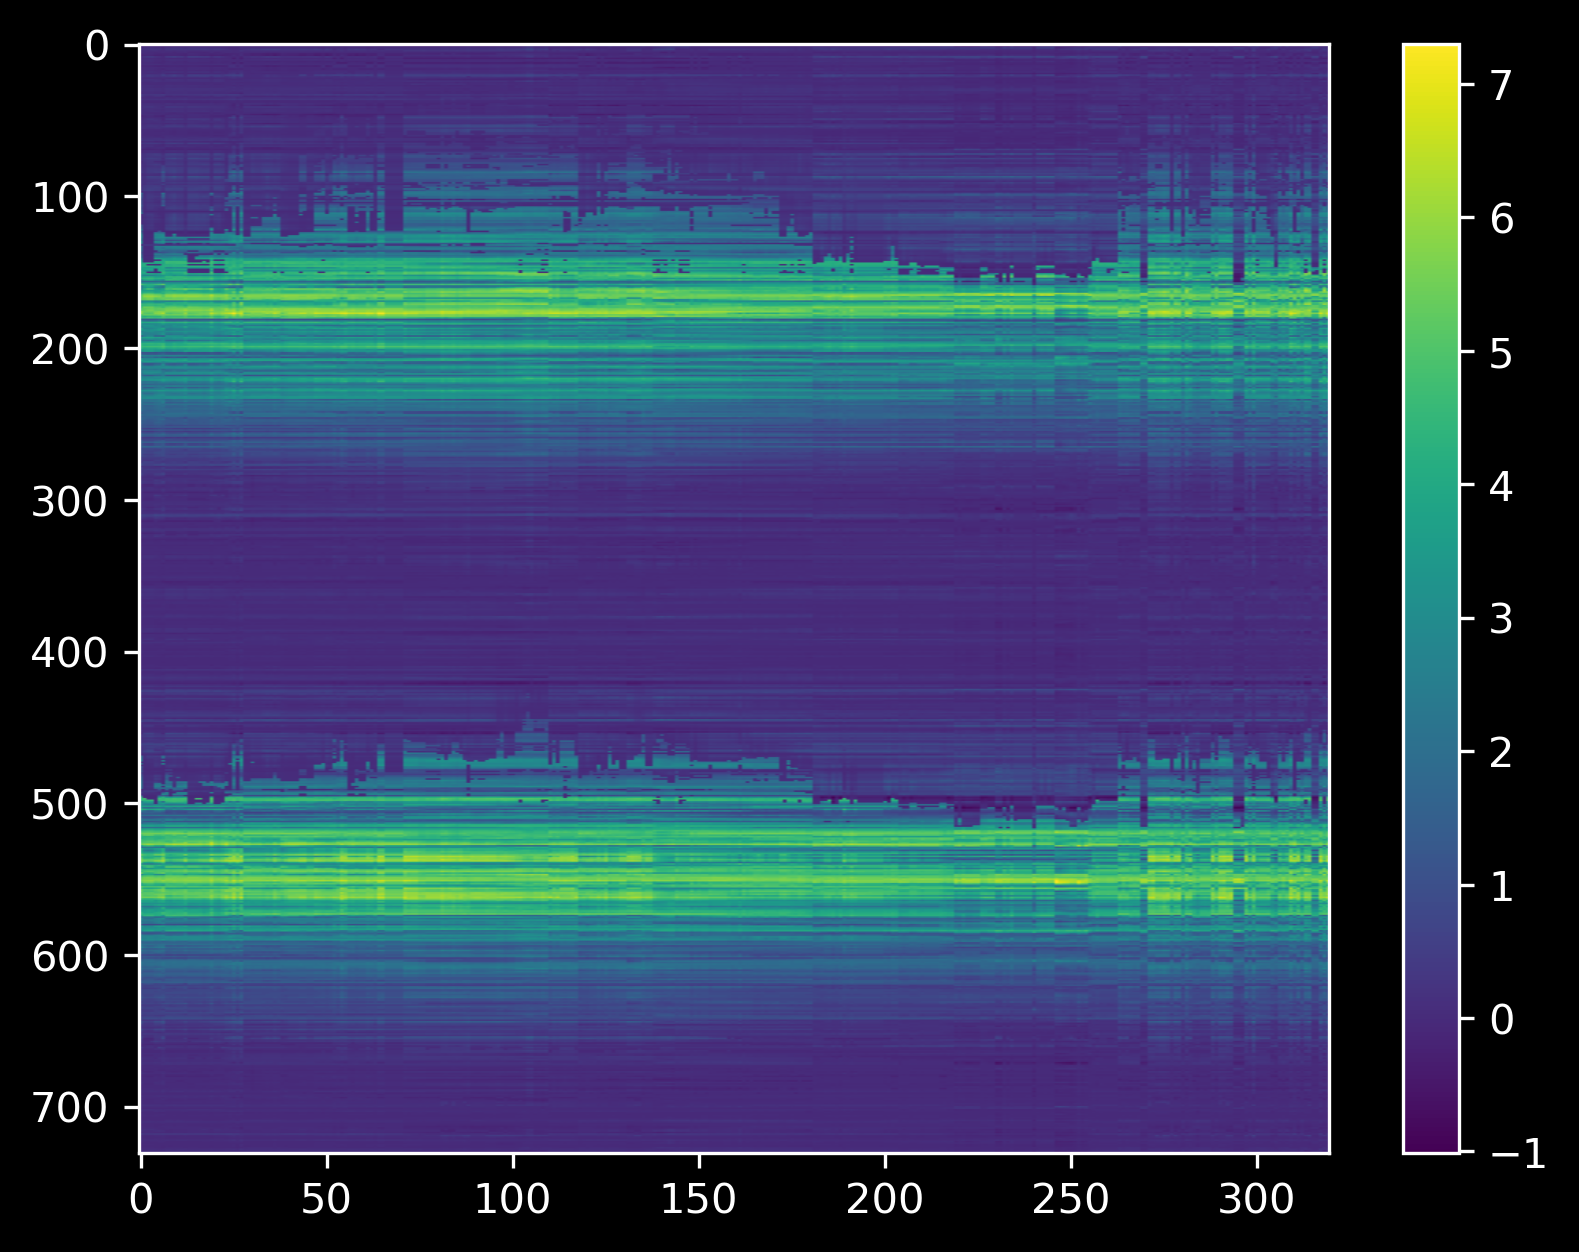

In [6]:
plt.imshow(pet.loc["2020":"2021"], aspect='auto')
plt.colorbar()

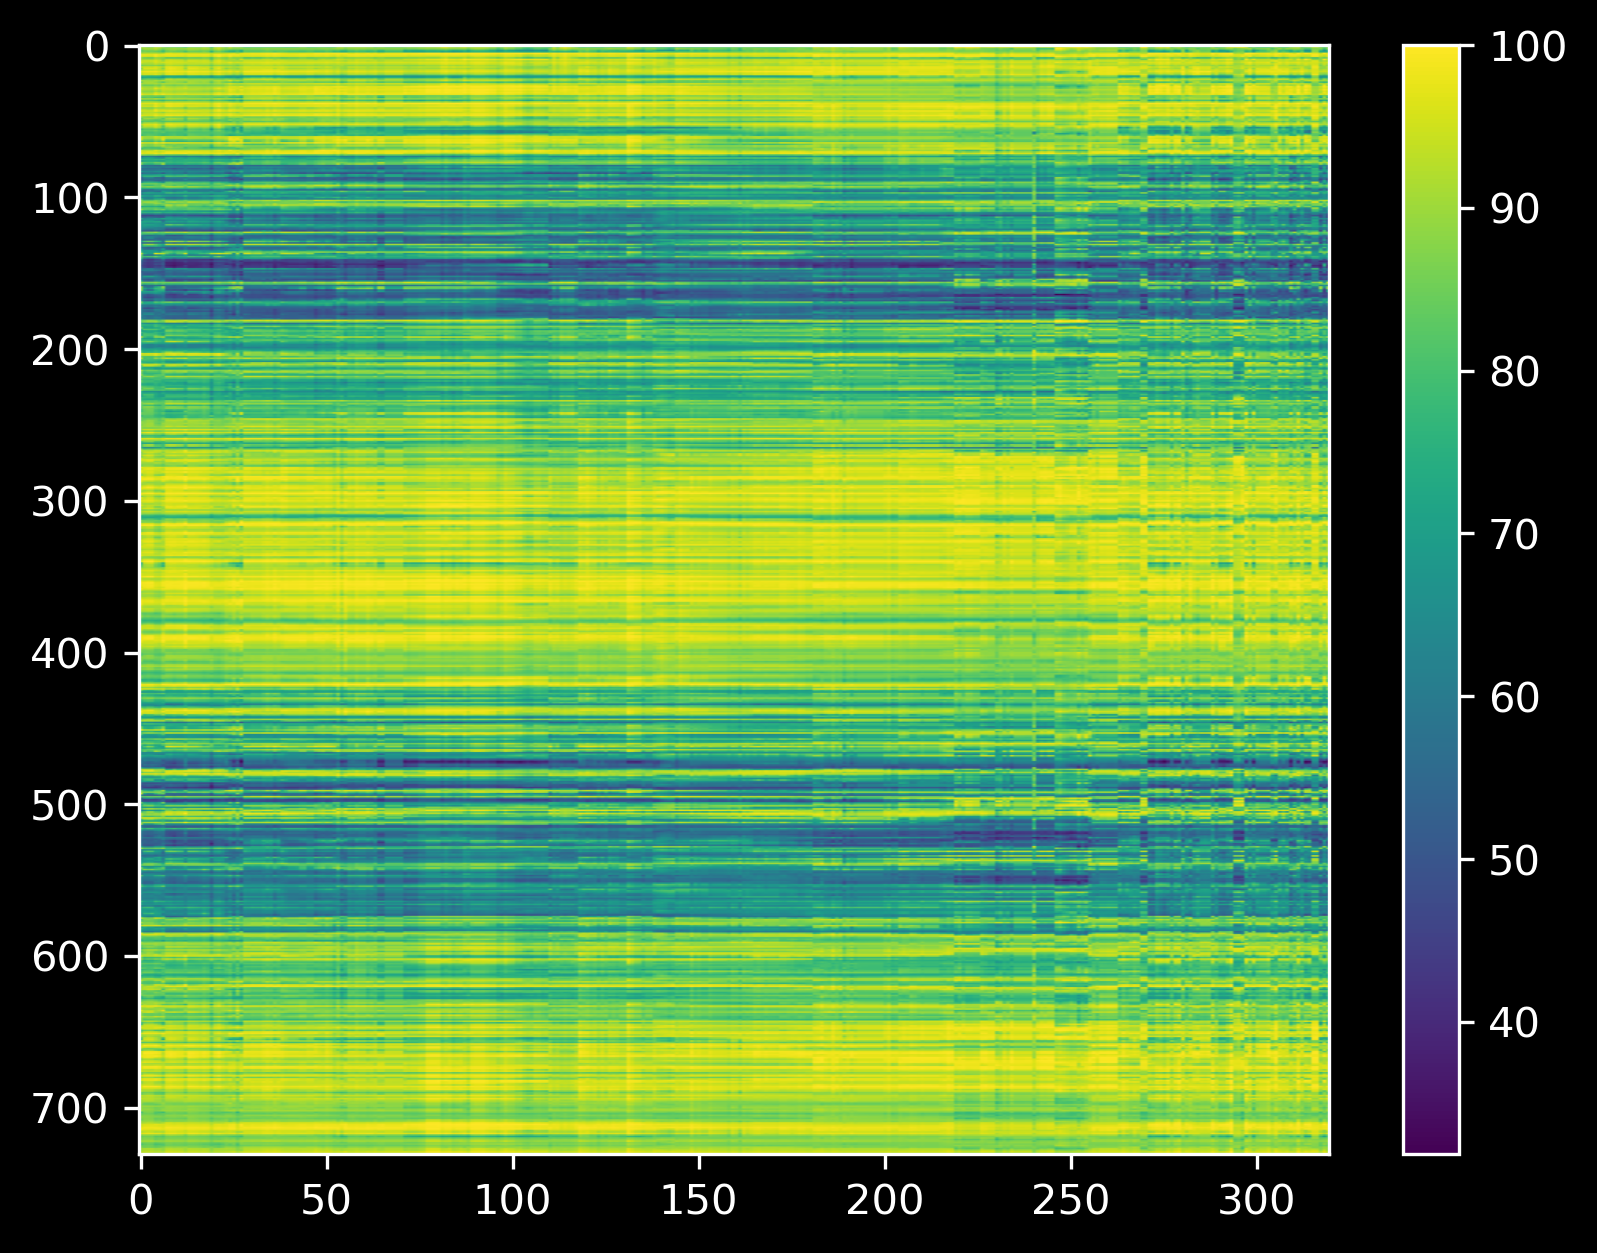

In [7]:
plt.imshow(humidity.loc["2020":"2021"], vmax=100, aspect='auto')
plt.colorbar()

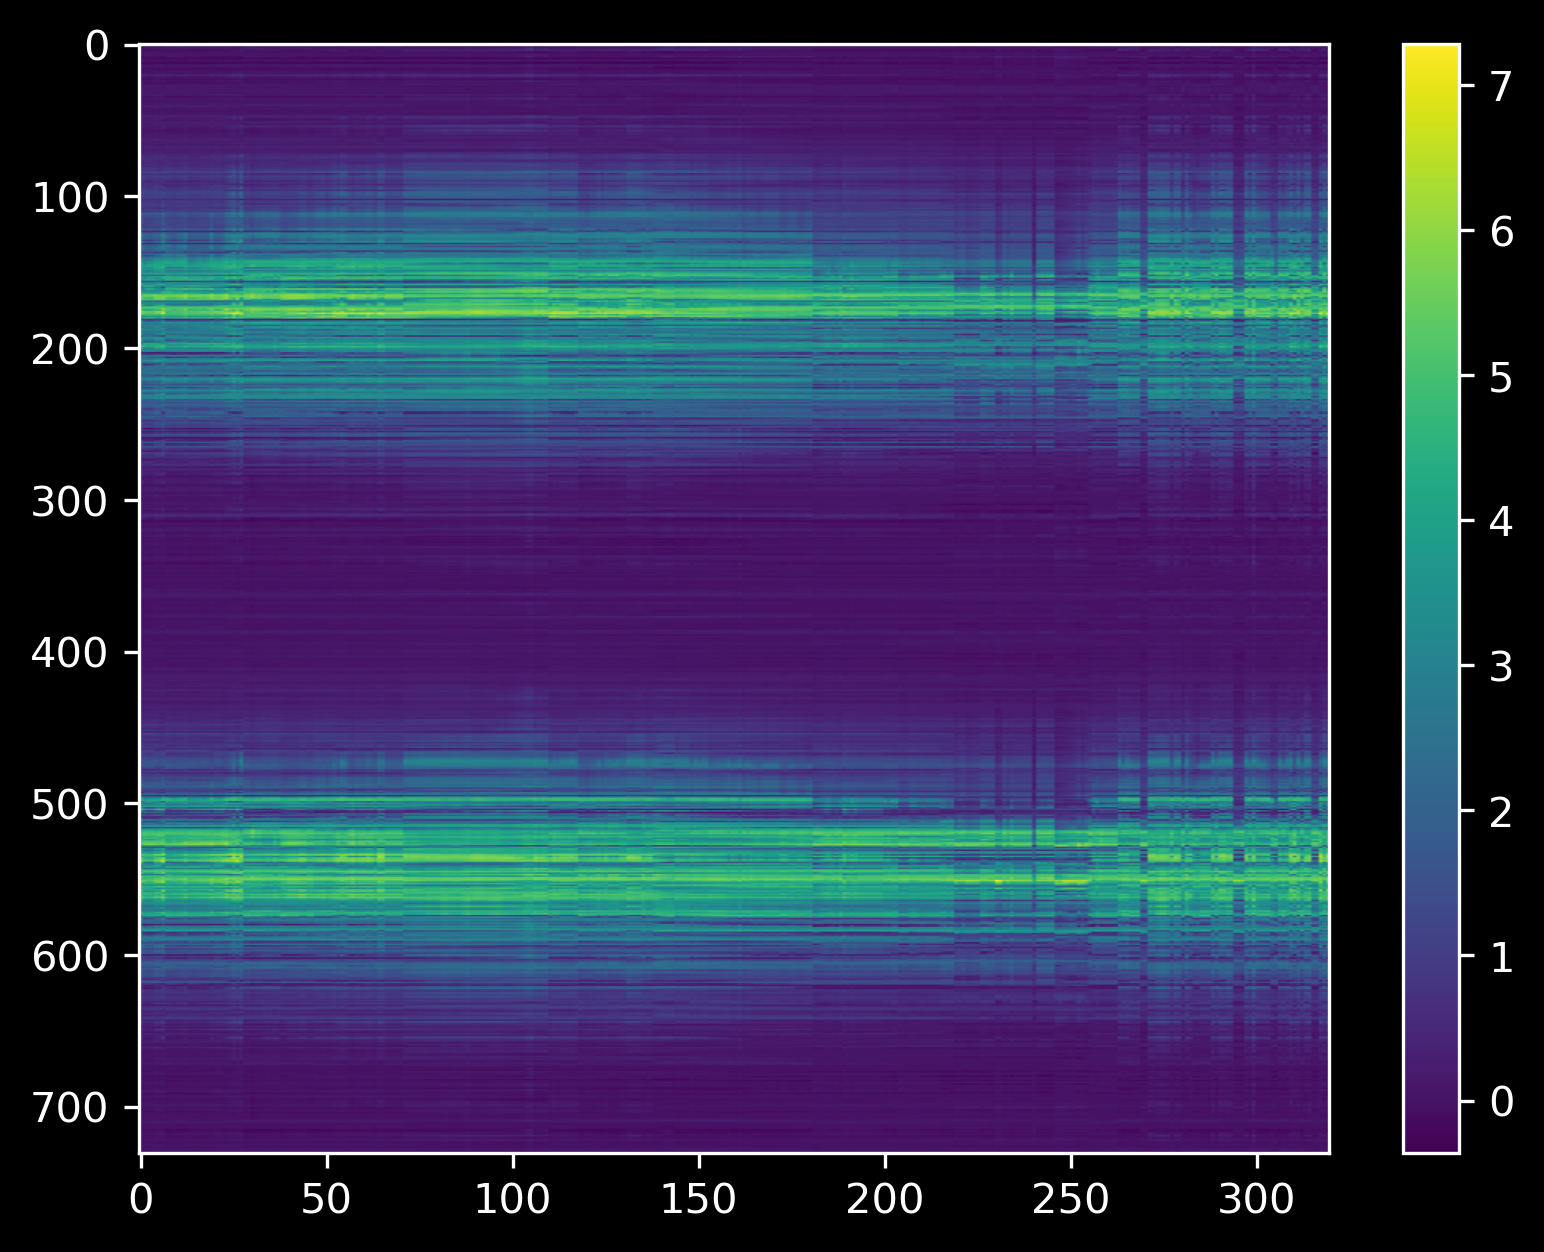

In [14]:
plt.imshow(singer.loc["2020":"2021"], aspect='auto')
plt.colorbar()

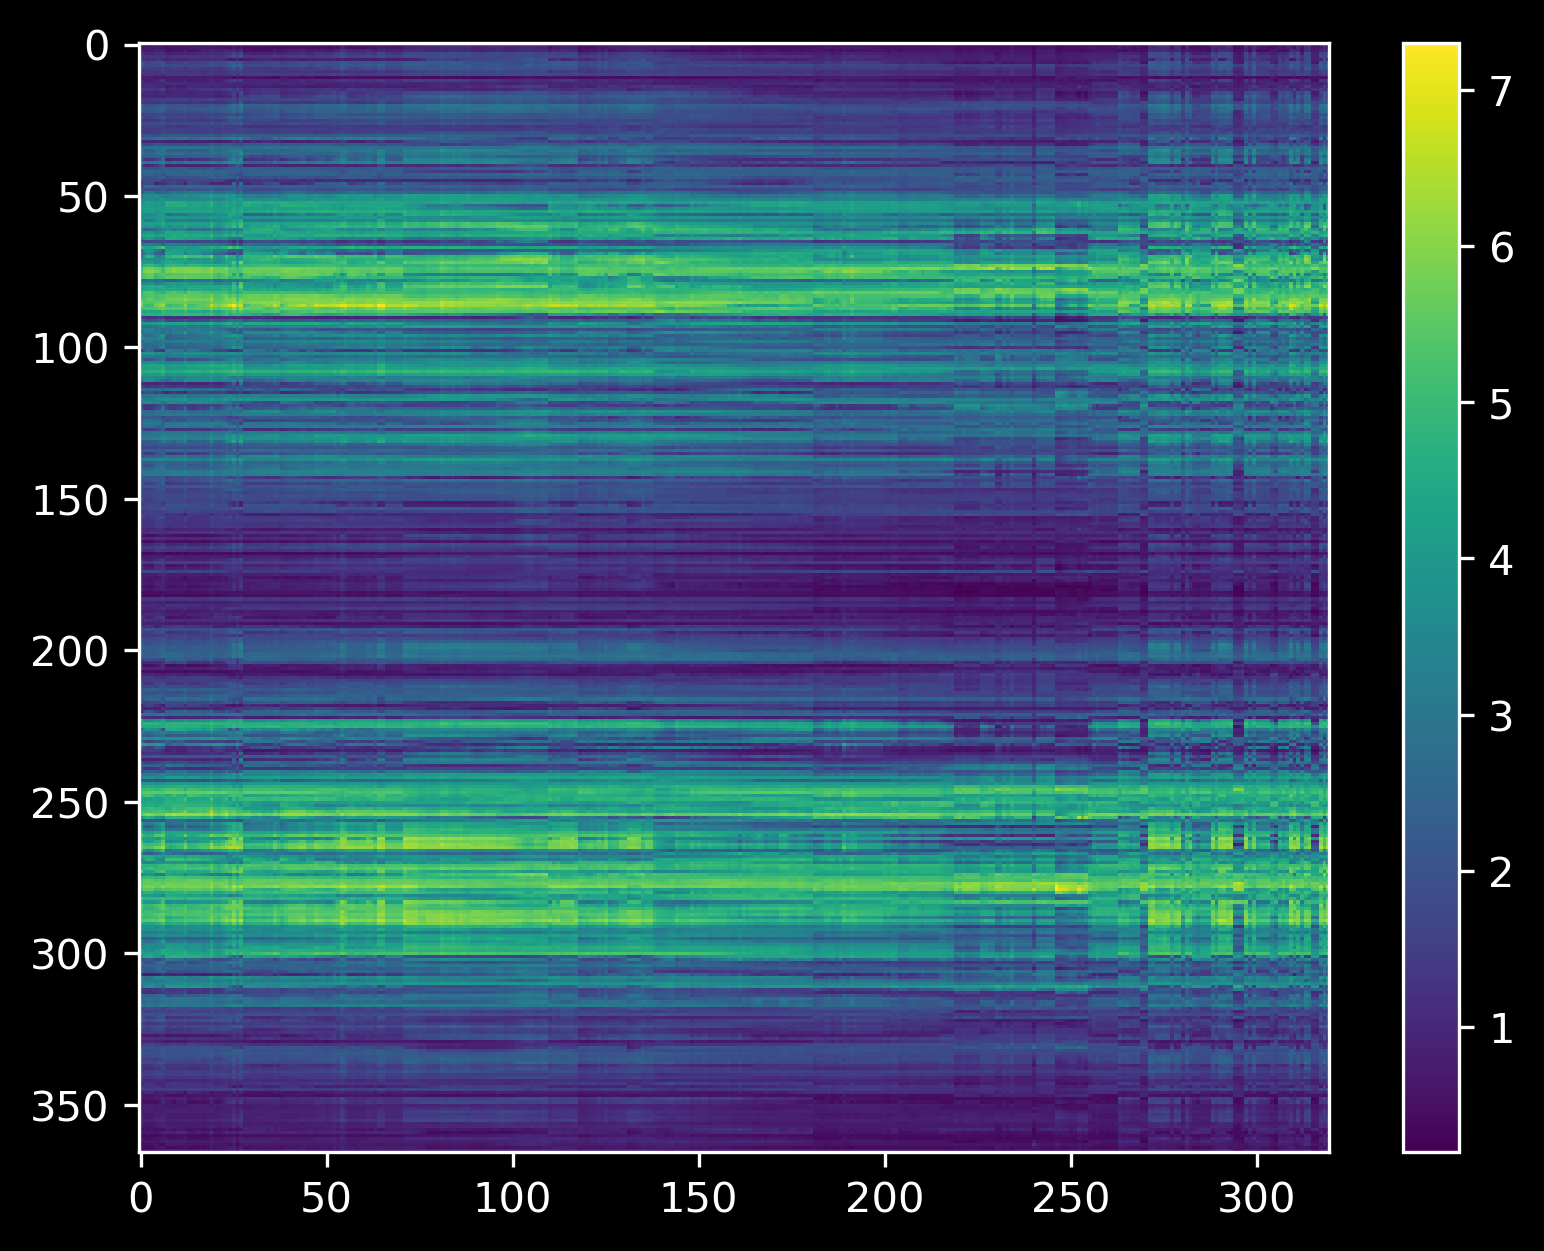

In [15]:
plt.imshow(fmi.loc["2020":"2021"], aspect='auto')
plt.colorbar()

In [16]:
marked = mark_dataset_usage(snow_depth, fmi, singer, snow_e)

In [17]:
transitions = find_transition_times(marked)

In [18]:
transitions

,location,timestamp,from,to
0,896,1961-01-01,None,snow_e
1,896,1961-05-05,snow_e,singer
2,896,1961-11-15,singer,snow_e
3,896,1961-11-16,snow_e,singer
4,896,1961-11-17,singer,snow_e
...,...,...,...,...
165818,3975,2023-10-27,singer,snow_e
165819,3975,2023-10-28,snow_e,singer
165820,3975,2023-10-31,singer,snow_e
165821,3975,2023-11-01,snow_e,singer


In [19]:
for i in range(10):
    filt_transitions = filter_isolated_transitions(transitions, min_days_between=(i))
    print(len(filt_transitions))

165503
165503
134427
118697
107739
99767
93392
87877
82839
79041


In [20]:
filt_transitions = filter_isolated_transitions(transitions, min_days_between=(4))


In [21]:
filt_transitions

,location,timestamp,from,to
0,1000,1961-01-01,None,snow_e
1,1000,1961-11-14,singer,snow_e
2,1000,1961-11-29,singer,snow_e
3,1000,1962-04-24,snow_e,singer
4,1000,1962-04-29,singer,snow_e
...,...,...,...,...
107734,996,2022-11-17,singer,snow_e
107735,996,2023-05-10,snow_e,fmi
107736,996,2023-10-01,fmi,singer
107737,996,2023-10-29,singer,snow_e


In [22]:
(filt_transitions['from'] == 'fmi').sum()

np.int64(19382)

In [23]:
(filt_transitions['to'] == 'fmi').sum()

np.int64(14707)

In [24]:
(filt_transitions['from'] == 'snow_e').sum()

np.int64(40952)

In [25]:
(filt_transitions['to'] == 'snow_e').sum()

np.int64(52848)

In [26]:
(filt_transitions['from'] == 'singer').sum()

np.int64(47085)

In [27]:
(filt_transitions['to'] == 'singer').sum()

np.int64(40184)

In [76]:
fmi_to_singer = calculate_transition_changes(pet, marked, transitions, 'fmi', 'singer')

In [77]:
fmi_to_singer

,min_change,percentile_25,median_change,mean_change,avg_variation,percentile_75,max_change,count
fmi_to_singer,-1.26,-0.26,-0.11,-0.129765,0.264487,0.04,0.78,13667


In [78]:
fmi_to_singer = calculate_transition_changes(pet, marked, filt_transitions, 'fmi', 'singer')

In [79]:
fmi_to_singer

,min_change,percentile_25,median_change,mean_change,avg_variation,percentile_75,max_change,count
fmi_to_singer,-1.26,-0.26,-0.11,-0.129757,0.264825,0.04,0.78,13518


In [80]:
singer_to_snow_e = calculate_transition_changes(pet, marked, transitions, 'singer', 'snow_e')

In [81]:
singer_to_snow_e

,min_change,percentile_25,median_change,mean_change,avg_variation,percentile_75,max_change,count
singer_to_snow_e,-2.11,-0.15,-0.03,-0.076997,0.201998,0.03,0.54,42985


In [82]:
singer_to_snow_e = calculate_transition_changes(pet, marked, filt_transitions, 'singer', 'snow_e')

In [83]:
singer_to_snow_e

,min_change,percentile_25,median_change,mean_change,avg_variation,percentile_75,max_change,count
singer_to_snow_e,-2.11,-0.16,-0.04,-0.081376,0.19934,0.03,0.54,30850


In [84]:
snow_e_to_fmi = calculate_transition_changes(pet, marked, transitions, 'snow_e', 'fmi')

In [85]:
snow_e_to_fmi

,min_change,percentile_25,median_change,mean_change,avg_variation,percentile_75,max_change,count
snow_e_to_fmi,-0.87,1.08,1.7,1.729739,0.985253,2.31,5.8,23610


In [86]:
snow_e_to_fmi = calculate_transition_changes(pet, marked, filt_transitions, 'snow_e', 'fmi')

In [87]:
snow_e_to_fmi

,min_change,percentile_25,median_change,mean_change,avg_variation,percentile_75,max_change,count
snow_e_to_fmi,-0.87,1.13,1.8,1.813159,1.033056,2.4875,5.64,14294


In [88]:
calculate_transition_changes(pet, marked, filt_transitions, 'fmi', 'snow_e')

,min_change,percentile_25,median_change,mean_change,avg_variation,percentile_75,max_change,count
fmi_to_snow_e,-5.1,-1.8,-1.28,-1.37744,0.823688,-0.8,0.35,5864


In [89]:
calculate_transition_changes(pet, marked, filt_transitions, 'singer', 'fmi')

,min_change,percentile_25,median_change,mean_change,avg_variation,percentile_75,max_change,count
singer_to_fmi,-2.12,-0.26,-0.07,-0.076973,0.316408,0.1,0.93,413


In [90]:
calculate_transition_changes(pet, marked, filt_transitions, 'snow_e', 'singer')

,min_change,percentile_25,median_change,mean_change,avg_variation,percentile_75,max_change,count
snow_e_to_singer,-0.72,0.03,0.1,0.16917,0.240346,0.22,1.84,14343


## Calculating the typical variation

In [72]:
pre_variation = calculate_pre_transition_variation(pet, marked, filt_transitions, days=4)
post_variation = calculate_post_transition_variation(pet, marked, filt_transitions, days=4)

In [68]:
pre_variation

,location,timestamp,source,avg_variation
0,1000,1981-05-11,snow_e,0.389744
1,1000,1981-10-01,fmi,0.309570
2,1000,1981-10-27,singer,0.093274
3,1000,1982-05-07,snow_e,0.009574
4,1000,1982-10-01,fmi,0.244949
...,...,...,...,...
79277,996,2022-11-17,singer,0.015000
79278,996,2023-05-10,snow_e,0.087560
79279,996,2023-10-01,fmi,0.125831
79280,996,2023-10-29,singer,0.047958


In [73]:
sources = ['fmi', 'singer', 'snow_e']

for source in sources:
    pre = pre_variation[pre_variation['source'] == source]
    spring_pre, fall_pre = split_year_halves(pre)
    print(f'{source} spring pre variation: {spring_pre.avg_variation.mean()}, count {len(spring_pre.avg_variation)}')
    print(f'{source} fall pre variation: {fall_pre.avg_variation.mean()}, count {len(fall_pre.avg_variation)}')
    post = post_variation[post_variation['source'] == source]
    spring_post, fall_post = split_year_halves(post)
    print(f'{source} spring post variation: {spring_post.avg_variation.mean()}, count {len(spring_post.avg_variation)}')
    print(f'{source} autumn post variation: {fall_post.avg_variation.mean()}, count {len(fall_post.avg_variation)}')

fmi spring pre variation: 0.534676472595407, count 5382
fmi fall pre variation: 0.18480599952359641, count 14000
fmi spring post variation: 0.6067752863514273, count 14675
fmi autumn post variation: 0.20868903757096416, count 32
singer spring pre variation: 0.1680896081994139, count 2914
singer fall pre variation: 0.10992210256530809, count 28349
singer spring post variation: 0.1961517604426082, count 2552
singer autumn post variation: 0.13314106568530723, count 25309
snow_e spring pre variation: 0.09823100399601711, count 16814
snow_e fall pre variation: 0.07635653344604201, count 11823
snow_e spring post variation: 0.5405540811664838, count 7883
snow_e autumn post variation: 0.07836270695163869, count 28831


In [88]:
split_year_halves(pre)[0].avg_variation.mean()

np.float64(0.534676472595407)

In [89]:
split_year_halves(pre)[1].avg_variation.mean()

np.float64(0.18480599952359641)

In [81]:
pre.timestamp.

1       1981-10-01
4       1982-10-01
12      1983-10-01
17      1984-05-08
18      1984-10-01
           ...    
79263   2020-10-01
79268   2021-05-06
79269   2021-10-01
79275   2022-10-01
79279   2023-10-01
Name: timestamp, Length: 19382, dtype: datetime64[ns]